# Week 6 — The Gymnasium Ecosystem
## From env_registry to Atari: a panorama

**From Conway to LangGraph** · Università di Bologna · Dipartimento di Fisica

---

In Week 6 we used **CartPole** and **FrozenLake** — two environments that span the fundamental axes of RL difficulty (continuous/discrete state × dense/sparse reward). This notebook zooms out and maps the full Gymnasium ecosystem, then dives into the Atari suite as a concrete demonstration of pixel-based deep RL.

**Notebook structure:**

| Part | Content |
|------|--------|
| 1 | Installation and imports |
| 2 | Exploring `gymnasium.envs.registry` |
| 3 | Phase diagram of all environments |
| 4 | Atari setup and environment anatomy |
| 5 | Pong — random agent vs pretrained DQN |
| 6 | MsPacman — random agent vs pretrained DQN |
| 7 | Quantitative comparison and score distributions |
| 8 | Exercises |

# Part 1 — Installation

In [21]:
!pip install "gymnasium[atari]" ale-py -q
!pip install stable-baselines3 -q
!pip install huggingface-sb3 --no-deps -q
!pip install "huggingface-hub>=1.3.0" -q
!pip install "shimmy>=0.2.1" -q
!AutoROM --accept-license
print('Installation complete.')

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Installation complete.


In [9]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import gymnasium as gym
import ale_py
from gymnasium.envs.registration import registry
from collections import defaultdict
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Register ALE environments explicitly
gym.register_envs(ale_py)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print(f'Gymnasium version: {gym.__version__}')
print(f'ALE version: {ale_py.__version__}')
print(f'Total registered environments: {len(registry)}')

Gymnasium version: 1.2.3
ALE version: 0.11.2
Total registered environments: 415


# Part 2 — Exploring `gymnasium.envs.registry`

Every Gymnasium environment is registered in a global dictionary `gymnasium.envs.registry`.  
Each entry is an `EnvSpec` object containing the environment ID, entry point, max episode steps, and other metadata.

We will:
1. Enumerate all registered IDs
2. Classify them by family (Classic Control, Box2D, MuJoCo, Atari, Toy Text, …)
3. Display a structured summary table

In [10]:
# ── 2.1  Raw registry inspection ──────────────────────────────────────────

# The registry is a dict: {env_id: EnvSpec}
all_ids = sorted(registry.keys())

print(f'Total environments: {len(all_ids)}\n')
print('First 15 IDs (alphabetical):')
for env_id in all_ids[:15]:
    spec = registry[env_id]
    max_steps = spec.max_episode_steps
    print(f'  {env_id:<40}  max_steps={max_steps}')

print('\n...')
print('\nLast 5 IDs:')
for env_id in all_ids[-5:]:
    print(f'  {env_id}')

Total environments: 415

First 15 IDs (alphabetical):
  ALE/Adventure-v5                          max_steps=None
  ALE/AirRaid-v5                            max_steps=None
  ALE/Alien-v5                              max_steps=None
  ALE/Amidar-v5                             max_steps=None
  ALE/Assault-v5                            max_steps=None
  ALE/Asterix-v5                            max_steps=None
  ALE/Asteroids-v5                          max_steps=None
  ALE/Atlantis-v5                           max_steps=None
  ALE/Atlantis2-v5                          max_steps=None
  ALE/Backgammon-v5                         max_steps=None
  ALE/BankHeist-v5                          max_steps=None
  ALE/BasicMath-v5                          max_steps=None
  ALE/BattleZone-v5                         max_steps=None
  ALE/BeamRider-v5                          max_steps=None
  ALE/Berzerk-v5                            max_steps=None

...

Last 5 IDs:
  phys2d/CartPole-v0
  phys2d/CartPole-v1
 

In [11]:
# ── 2.2  Classify by family ────────────────────────────────────────────────

FAMILY_PATTERNS = {
    'Atari / ALE':      r'^ALE/',
    'MuJoCo':           r'(HalfCheetah|Hopper|Walker2d|Ant|Humanoid|Swimmer|Reacher|Pusher|InvertedPendulum|InvertedDoublePendulum)',
    'Box2D':            r'(LunarLander|BipedalWalker|CarRacing)',
    'Classic Control':  r'(CartPole|MountainCar|Pendulum|Acrobot)',
    'Toy Text':         r'(FrozenLake|Taxi|CliffWalking|Blackjack|NChain|Roulette)',
    'Robotics / Fetch': r'(Fetch|Hand|Adroit)',
    'Third-party':      r'(minigrid|miniworld|highway)',
}

family_counts = defaultdict(list)

for env_id in all_ids:
    matched = False
    for family, pattern in FAMILY_PATTERNS.items():
        if re.search(pattern, env_id, re.IGNORECASE):
            family_counts[family].append(env_id)
            matched = True
            break
    if not matched:
        family_counts['Other'].append(env_id)

print(f'{"Family":<25}  {"Count":>6}  Example IDs')
print('-' * 75)
for family, ids in sorted(family_counts.items(), key=lambda x: -len(x[1])):
    examples = ', '.join(ids[:3])
    if len(ids) > 3:
        examples += f', … (+{len(ids)-3} more)'
    print(f'{family:<25}  {len(ids):>6}  {examples}')

Family                      Count  Example IDs
---------------------------------------------------------------------------
Other                         242  Adventure-v0, Adventure-v4, AdventureNoFrameskip-v0, … (+239 more)
Atari / ALE                   104  ALE/Adventure-v5, ALE/AirRaid-v5, ALE/Alien-v5, … (+101 more)
MuJoCo                         47  Ant-v2, Ant-v3, Ant-v4, … (+44 more)
Classic Control                 9  Acrobot-v1, CartPole-v0, CartPole-v1, … (+6 more)
Toy Text                        8  Blackjack-v1, CliffWalking-v1, CliffWalkingSlippery-v1, … (+5 more)
Box2D                           5  BipedalWalker-v3, BipedalWalkerHardcore-v3, CarRacing-v3, … (+2 more)


In [12]:
# ── 2.3  Inspect a single EnvSpec in detail ────────────────────────────────

spec = registry['CartPole-v1']

print('EnvSpec for CartPole-v1:')
print(f'  id                : {spec.id}')
print(f'  entry_point       : {spec.entry_point}')
print(f'  max_episode_steps : {spec.max_episode_steps}')
print(f'  reward_threshold  : {spec.reward_threshold}')
print(f'  kwargs            : {spec.kwargs}')

print()
spec_fl = registry['FrozenLake-v1']
print('EnvSpec for FrozenLake-v1:')
print(f'  id                : {spec_fl.id}')
print(f'  max_episode_steps : {spec_fl.max_episode_steps}')
print(f'  reward_threshold  : {spec_fl.reward_threshold}')
print(f'  kwargs            : {spec_fl.kwargs}')

EnvSpec for CartPole-v1:
  id                : CartPole-v1
  entry_point       : gymnasium.envs.classic_control.cartpole:CartPoleEnv
  max_episode_steps : 500
  reward_threshold  : 475.0
  kwargs            : {}

EnvSpec for FrozenLake-v1:
  id                : FrozenLake-v1
  max_episode_steps : 100
  reward_threshold  : 0.7
  kwargs            : {'map_name': '4x4'}


In [13]:
# ── 2.4  Observation and action space summary for selected environments ────

SELECTED = [
    'CartPole-v1',
    'MountainCar-v0',
    'Pendulum-v1',
    'Acrobot-v1',
    'LunarLander-v2',
    'FrozenLake-v1',
    'CliffWalking-v0',
    'Taxi-v3',
    'Blackjack-v1',
    'ALE/Pong-v5',
    'ALE/MsPacman-v5',
]

print(f'{"Environment":<25}  {"Obs space":<35}  {"Action space":<25}  MaxSteps')
print('-' * 100)

for env_id in SELECTED:
    try:
        env = gym.make(env_id)
        obs_str  = str(env.observation_space)[:34]
        act_str  = str(env.action_space)[:24]
        spec     = registry[env_id]
        max_s    = spec.max_episode_steps
        print(f'{env_id:<25}  {obs_str:<35}  {act_str:<25}  {max_s}')
        env.close()
    except Exception as e:
        print(f'{env_id:<25}  ERROR: {e}')

Environment                Obs space                            Action space               MaxSteps
----------------------------------------------------------------------------------------------------
CartPole-v1                Box([-4.8               -inf -0.41   Discrete(2)                500
MountainCar-v0             Box([-1.2  -0.07], [0.6  0.07], (2   Discrete(3)                200
Pendulum-v1                Box([-1. -1. -8.], [1. 1. 8.], (3,   Box(-2.0, 2.0, (1,), flo   200
Acrobot-v1                 Box([ -1.        -1.        -1.      Discrete(3)                500
LunarLander-v2             ERROR: Environment version v2 for `LunarLander` is deprecated. Please use `LunarLander-v3` instead.
FrozenLake-v1              Discrete(16)                         Discrete(4)                100
CliffWalking-v0            ERROR: Environment version v0 for `CliffWalking` is deprecated. Please use `CliffWalking-v1` instead.
Taxi-v3                    Discrete(500)                        Disc

# Part 3 — Phase Diagram of Gymnasium Environments

Every environment can be characterised by two axes:
- **State/observation type**: discrete (finite set) vs continuous (real-valued)
- **Reward density**: dense (informative at every step) vs sparse (near-zero almost everywhere)

This gives a 2×2 **phase diagram** that directly maps to algorithmic requirements.  
The analogy with statistical mechanics: the two axes play the role of temperature and external field.

> **Physics framing**: Dense reward ≈ confining harmonic potential (clear gradient everywhere).  
> Sparse reward ≈ flat potential with a delta-function sink (gradient is useless; need Monte Carlo exploration).

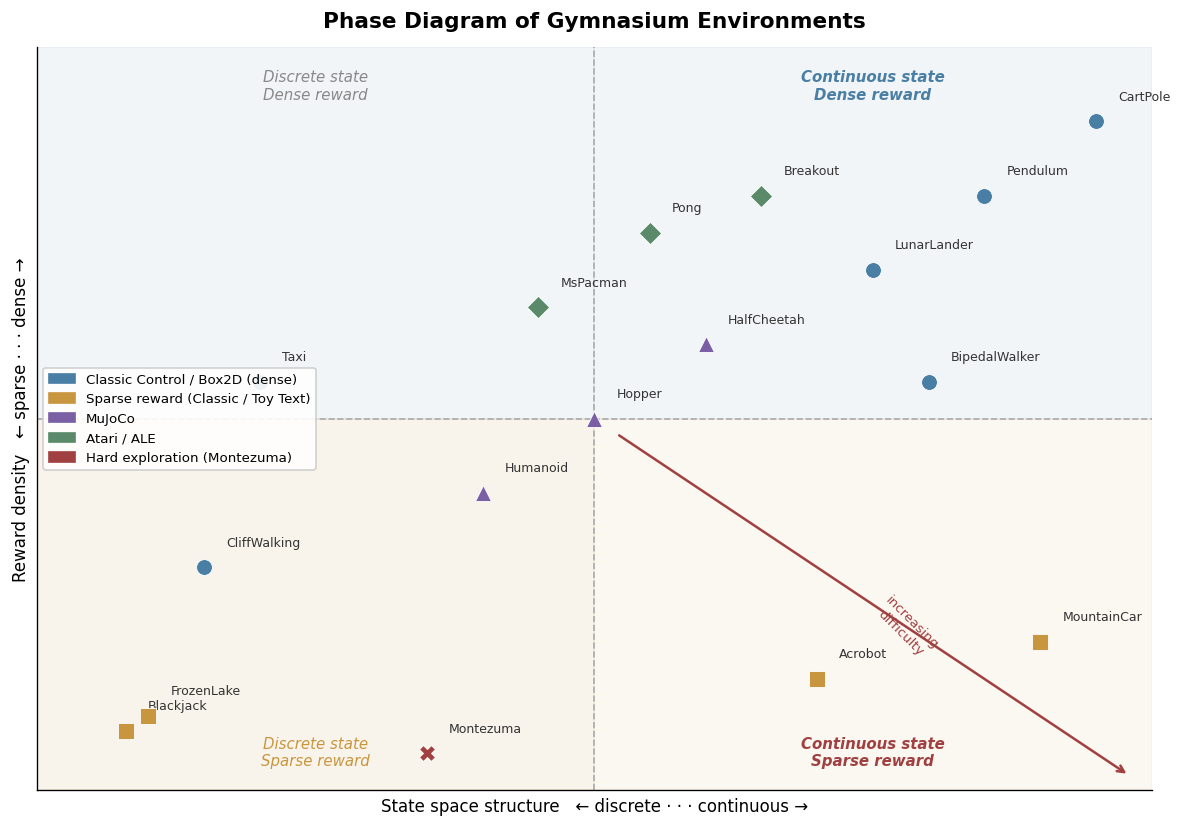

CartPole and FrozenLake span the diagonal — they are our two reference points.


In [14]:
# ── 3.1  Phase diagram visualisation ──────────────────────────────────────

# Each entry: (name, x, y, marker)
# x: 0=discrete state, 1=continuous state
# y: 0=sparse reward,  1=dense reward
# Small jitter added manually for readability

ENVS_PHASE = [
    # name,                x,     y,     color,       marker
    ('CartPole-v1',        0.95,  0.90,  '#4A7FA5',   'o'),
    ('Pendulum-v1',        0.85,  0.80,  '#4A7FA5',   'o'),
    ('LunarLander-v2',     0.75,  0.70,  '#4A7FA5',   'o'),
    ('BipedalWalker-v3',   0.80,  0.55,  '#4A7FA5',   'o'),
    ('MountainCar-v0',     0.90,  0.20,  '#C8963E',   's'),
    ('Acrobot-v1',         0.70,  0.15,  '#C8963E',   's'),
    ('HalfCheetah-v4',     0.60,  0.60,  '#7A5FA5',   '^'),
    ('Hopper-v4',          0.50,  0.50,  '#7A5FA5',   '^'),
    ('Humanoid-v4',        0.40,  0.40,  '#7A5FA5',   '^'),
    ('FrozenLake-v1',      0.10,  0.10,  '#C8963E',   's'),
    ('CliffWalking-v0',    0.15,  0.30,  '#4A7FA5',   'o'),
    ('Taxi-v3',            0.20,  0.55,  '#4A7FA5',   'o'),
    ('Blackjack-v1',       0.08,  0.08,  '#C8963E',   's'),
    ('Pong-v5',            0.55,  0.75,  '#5A8A6A',   'D'),
    ('MsPacman-v5',        0.45,  0.65,  '#5A8A6A',   'D'),
    ('Breakout-v5',        0.65,  0.80,  '#5A8A6A',   'D'),
    ('Montezuma-v5',       0.35,  0.05,  '#A04040',   'X'),
]

fig, ax = plt.subplots(figsize=(10, 7))

# Quadrant shading
ax.axhspan(0.5, 1.0, xmin=0.5, xmax=1.0, alpha=0.07, color='#4A7FA5')
ax.axhspan(0.0, 0.5, xmin=0.5, xmax=1.0, alpha=0.07, color='#C8963E')
ax.axhspan(0.5, 1.0, xmin=0.0, xmax=0.5, alpha=0.07, color='#4A7FA5')
ax.axhspan(0.0, 0.5, xmin=0.0, xmax=0.5, alpha=0.10, color='#C8963E')

# Dividing lines
ax.axhline(0.5, color='#AAAAAA', lw=1.0, ls='--')
ax.axvline(0.5, color='#AAAAAA', lw=1.0, ls='--')

# Quadrant labels
ax.text(0.25, 0.97, 'Discrete state\nDense reward', ha='center', va='top',
        fontsize=9, color='#888888', style='italic')
ax.text(0.75, 0.97, 'Continuous state\nDense reward', ha='center', va='top',
        fontsize=9, color='#4A7FA5', style='italic', weight='bold')
ax.text(0.25, 0.03, 'Discrete state\nSparse reward', ha='center', va='bottom',
        fontsize=9, color='#C8963E', style='italic')
ax.text(0.75, 0.03, 'Continuous state\nSparse reward', ha='center', va='bottom',
        fontsize=9, color='#A04040', style='italic', weight='bold')

# Difficulty arrow
ax.annotate('', xy=(0.98, 0.02), xytext=(0.52, 0.48),
            arrowprops=dict(arrowstyle='->', color='#A04040', lw=1.5))
ax.text(0.78, 0.22, 'increasing\ndifficulty', ha='center', va='center',
        fontsize=8, color='#A04040', rotation=-45)

# Plot environments
for name, x, y, color, marker in ENVS_PHASE:
    short = name.replace('-v5','').replace('-v4','').replace('-v3','').replace('-v2','').replace('-v1','').replace('-v0','')
    ax.scatter(x, y, c=color, marker=marker, s=90, zorder=5, edgecolors='white', linewidths=0.5)
    offset_x = 0.02
    offset_y = 0.025
    ax.text(x + offset_x, y + offset_y, short, fontsize=7.5, color='#333333', va='bottom')

# Legend
legend_elements = [
    mpatches.Patch(color='#4A7FA5', label='Classic Control / Box2D (dense)'),
    mpatches.Patch(color='#C8963E', label='Sparse reward (Classic / Toy Text)'),
    mpatches.Patch(color='#7A5FA5', label='MuJoCo'),
    mpatches.Patch(color='#5A8A6A', label='Atari / ALE'),
    mpatches.Patch(color='#A04040', label='Hard exploration (Montezuma)'),
]
ax.legend(handles=legend_elements, loc='center left', fontsize=8,
          framealpha=0.9, edgecolor='#CCCCCC')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('State space structure   ← discrete · · · continuous →', fontsize=10)
ax.set_ylabel('Reward density   ← sparse · · · dense →', fontsize=10)
ax.set_title('Phase Diagram of Gymnasium Environments', fontsize=13, weight='bold', pad=12)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.savefig('gymnasium_phase_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('CartPole and FrozenLake span the diagonal — they are our two reference points.')

# Part 4 — Atari: Setup and Environment Anatomy

The Atari Learning Environment (ALE) wraps 57 Atari 2600 games as Gymnasium environments.  
They share a common interface but differ substantially in reward structure, visual complexity, and exploration difficulty.

**Key technical details common to all Atari envs:**
- Observation: raw pixel frame, `(210, 160, 3)` RGB
- Frame rate: 60 Hz → actions repeated every 4 frames (frame skipping)
- Action space: 4–18 discrete actions (game-dependent subset of 18 joystick positions)
- Reward: game score increment per step

**Standard preprocessing pipeline (from the DQN paper, Mnih et al. 2015):**
1. Convert RGB → greyscale
2. Resize 210×160 → 84×84
3. Stack 4 consecutive frames → state ∈ ℝ^(84×84×4)
4. Clip rewards to {−1, 0, +1}

In Gymnasium, all of this is handled automatically by the `AtariPreprocessing` wrapper.

In [15]:
# ── 4.1  Anatomy of an Atari environment ──────────────────────────────────

from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation

# Raw environment
env_raw = gym.make('ALE/Pong-v5', render_mode='rgb_array')
obs_raw, _ = env_raw.reset()

print('=== Raw Pong-v5 ===')
print(f'Observation shape : {obs_raw.shape}   (H x W x C, uint8 pixels)')
print(f'Observation dtype : {obs_raw.dtype}')
print(f'Action space      : {env_raw.action_space}  ({env_raw.action_space.n} actions)')
print(f'Action meanings   : {env_raw.unwrapped.get_action_meanings()}')
env_raw.close()

print()

# Preprocessed environment (DQN standard)
# frameskip=1 required: AtariPreprocessing handles frame skipping internally
env_pre = gym.make('ALE/Pong-v5', render_mode='rgb_array', frameskip=1)
env_pre = AtariPreprocessing(env_pre)
env_pre = FrameStackObservation(env_pre, stack_size=4)
obs_pre, _ = env_pre.reset()

print('=== Preprocessed (DQN pipeline) ===')
print(f'Observation shape : {obs_pre.shape}   (frames x H x W, greyscale)')
print(f'Observation dtype : {obs_pre.dtype}')
env_pre.close()

print()
print('State space compression:')
raw_bytes = 210 * 160 * 3
pre_bytes = 4 * 84 * 84
print(f'  Raw frame   : {raw_bytes:>7,} floats')
print(f'  Preprocessed: {pre_bytes:>7,} floats  ({100*pre_bytes/raw_bytes:.1f}% of raw)')

=== Raw Pong-v5 ===
Observation shape : (210, 160, 3)   (H x W x C, uint8 pixels)
Observation dtype : uint8
Action space      : Discrete(6)  (6 actions)
Action meanings   : ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']

=== Preprocessed (DQN pipeline) ===
Observation shape : (4, 84, 84)   (frames x H x W, greyscale)
Observation dtype : uint8

State space compression:
  Raw frame   : 100,800 floats
  Preprocessed:  28,224 floats  (28.0% of raw)


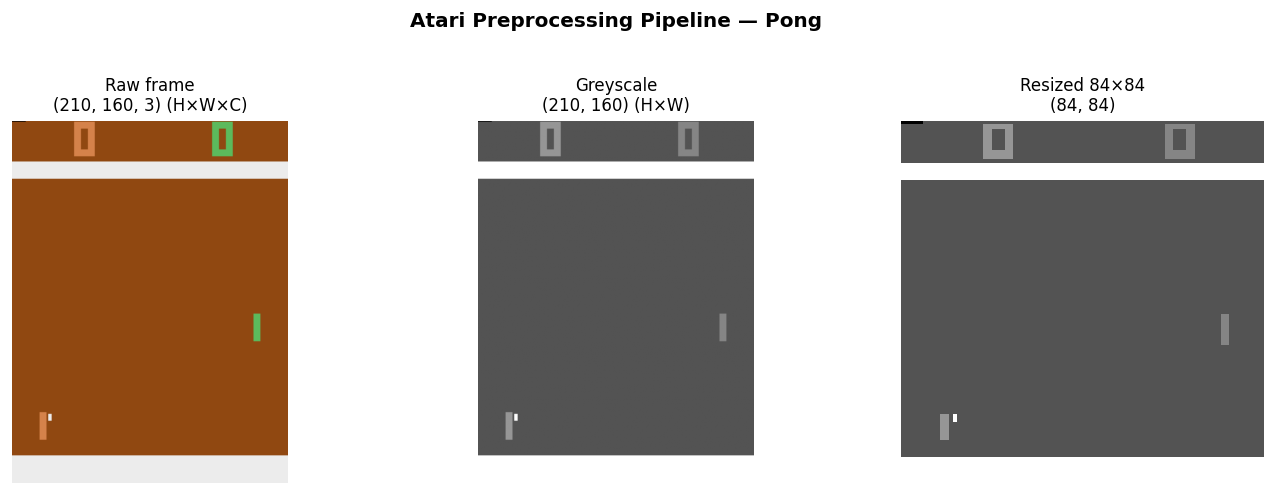

In [16]:
# ── 4.2  Visualise raw frame and preprocessing side by side ───────────────

import cv2

env_raw = gym.make('ALE/Pong-v5', render_mode='rgb_array')
obs_raw, _ = env_raw.reset(seed=42)

# Step a few times to get a non-trivial frame
for _ in range(30):
    obs_raw, _, term, trunc, _ = env_raw.step(env_raw.action_space.sample())
    if term or trunc:
        obs_raw, _ = env_raw.reset()

frame_rgb = env_raw.render()
env_raw.close()

# Manual preprocessing steps
frame_grey = np.mean(frame_rgb, axis=2).astype(np.uint8)
frame_small = np.array(
    [[frame_grey[int(i * 210/84), int(j * 160/84)]
      for j in range(84)] for i in range(84)], dtype=np.uint8
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(frame_rgb)
axes[0].set_title(f'Raw frame\n{frame_rgb.shape} (H×W×C)', fontsize=10)
axes[0].axis('off')

axes[1].imshow(frame_grey, cmap='gray')
axes[1].set_title(f'Greyscale\n{frame_grey.shape} (H×W)', fontsize=10)
axes[1].axis('off')

axes[2].imshow(frame_small, cmap='gray')
axes[2].set_title(f'Resized 84×84\n{frame_small.shape}', fontsize=10)
axes[2].axis('off')

plt.suptitle('Atari Preprocessing Pipeline — Pong', fontsize=12, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# ── 4.3  Compare Pong and MsPacman specs side by side ─────────────────────

for env_id in ['ALE/Pong-v5', 'ALE/MsPacman-v5']:
    env = gym.make(env_id, render_mode='rgb_array')
    obs, _ = env.reset(seed=0)
    meanings = env.unwrapped.get_action_meanings()
    spec = registry[env_id]
    print(f'{'='*50}')
    print(f'Environment       : {env_id}')
    print(f'Obs shape         : {obs.shape}')
    print(f'N actions         : {env.action_space.n}')
    print(f'Action meanings   : {meanings}')
    print(f'Max episode steps : {spec.max_episode_steps}')
    print(f'Reward threshold  : {spec.reward_threshold}')
    env.close()
    print()

Environment       : ALE/Pong-v5
Obs shape         : (210, 160, 3)
N actions         : 6
Action meanings   : ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']
Max episode steps : None
Reward threshold  : None

Environment       : ALE/MsPacman-v5
Obs shape         : (210, 160, 3)
N actions         : 9
Action meanings   : ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']
Max episode steps : None
Reward threshold  : None



# Part 5 — Pong: Random Agent vs Pretrained DQN

**Pong** is the simplest Atari environment — effectively a 1D tracking problem.  
A random agent scores around −21 (the opponent wins every point).  
A trained DQN scores +21 (perfect). The gap is stark and makes the learning signal very clear.

**Reward structure:** +1 for each point scored, −1 for each point conceded.  
Dense by Atari standards — the agent receives a non-zero reward every 20–30 frames.

**Physics framing:** Pong is a 1D pursuit problem with a bouncing ball.  
The state is approximately (ball_x, ball_y, ball_vx, ball_vy, paddle_y) — a 5D phase space.  
The optimal policy is a simple threshold: move paddle toward the predicted ball landing position.  
DQN learns this from pixels alone, without being given the physics equations.

In [24]:
# ── Helper: run one episode and collect frames + rewards ──────────────────

def run_episode(env, model=None, max_frames=1000, frame_skip=4, seed=42):
    """
    Run one episode.
    - model=None  → random agent
    - model=SB3   → call model.predict(obs)
    Returns: frames (list of RGB arrays), total_reward (float), step_rewards (list)
    """
    obs, _ = env.reset(seed=seed)
    frames = [env.render()]
    step_rewards = []
    total = 0.0
    step = 0

    while step < max_frames:
        if model is None:
            action = env.action_space.sample()
        else:
            action, _ = model.predict(obs, deterministic=True)

        obs, reward, terminated, truncated, _ = env.step(action)
        total += reward
        step_rewards.append(reward)

        if step % frame_skip == 0:
            frames.append(env.render())

        step += 1
        if terminated or truncated:
            break

    return frames, total, step_rewards


def run_multiple_episodes(env_id, model=None, n_episodes=5, seed_start=0):
    """Run n episodes and return list of total rewards."""
    env = gym.make(env_id, render_mode='rgb_array')
    rewards = []
    for i in range(n_episodes):
        _, total, _ = run_episode(env, model=model, seed=seed_start + i)
        rewards.append(total)
        print(f'  Episode {i+1}/{n_episodes}: reward = {total:.1f}')
    env.close()
    return rewards


def show_episode_frames(frames, title, n_cols=8):
    """Show a grid of evenly-spaced frames from an episode."""
    idxs = np.linspace(0, len(frames)-1, n_cols, dtype=int)
    fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 1.8, 2.4))
    for ax, idx in zip(axes, idxs):
        ax.imshow(frames[idx])
        ax.set_title(f't={idx}', fontsize=7)
        ax.axis('off')
    plt.suptitle(title, fontsize=11, weight='bold')
    plt.tight_layout()
    plt.show()

print('Helper functions defined.')

Helper functions defined.


Running random agent on Pong (5 episodes)...
Total reward (random): -21.0
Episode length: 900 steps


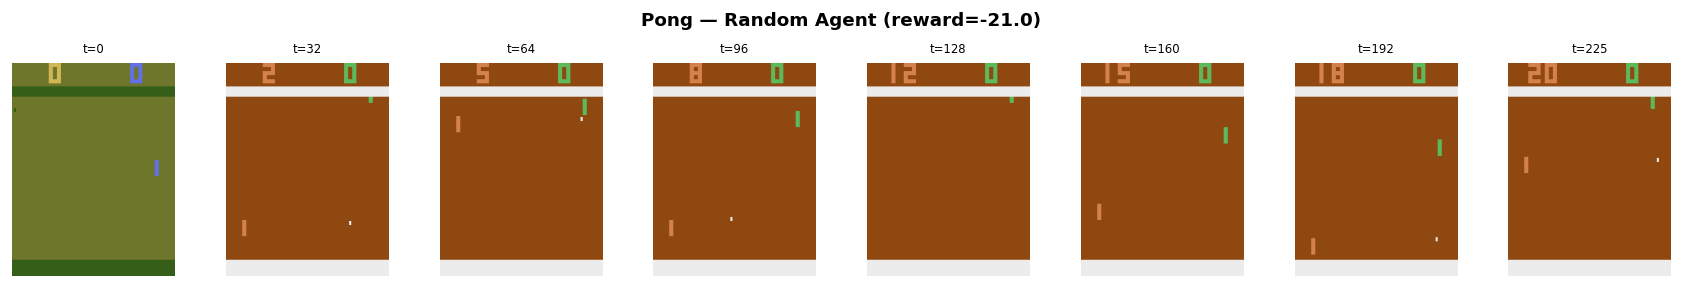

In [25]:
# ── 5.1  Pong — random agent ───────────────────────────────────────────────

print('Running random agent on Pong (5 episodes)...')
env_pong = gym.make('ALE/Pong-v5', render_mode='rgb_array')
frames_pong_rand, reward_pong_rand, step_rew_pong_rand = run_episode(
    env_pong, model=None, max_frames=2000, seed=0)
env_pong.close()

print(f'Total reward (random): {reward_pong_rand:.1f}')
print(f'Episode length: {len(step_rew_pong_rand)} steps')

show_episode_frames(frames_pong_rand, f'Pong — Random Agent (reward={reward_pong_rand:.1f})')

In [26]:
# ── 5.2  Load pretrained DQN for Pong ─────────────────────────────────────
from huggingface_hub import hf_hub_download
from stable_baselines3 import DQN

print('Downloading pretrained DQN for Pong...')

model_path = hf_hub_download(
    repo_id='sb3/dqn-PongNoFrameskip-v4',
    filename='dqn-PongNoFrameskip-v4.zip'
)

# Load without env to skip the space-mismatch check
# (the saved model has HWC layout; SB3's VecTransposeImage would flip it)
model_pong = DQN.load(model_path, custom_objects={
    'optimize_memory_usage': False,
    'handle_timeout_termination': True
})
print(f'Model loaded. Policy: {type(model_pong.policy).__name__}')
print(f'Model loaded. Policy: {type(model_pong.policy).__name__}')
print(f'Obs space in model: {model_pong.observation_space}')

Model loaded. Policy: CnnPolicy
Model loaded. Policy: CnnPolicy
Obs space in model: Box(0, 255, (4, 84, 84), uint8)


In [29]:
# ── Helper: run one episode with pretrained model (needs wrapped env) ─────────
def run_episode_pretrained(env_id, model, max_frames=2000, frame_skip=4, seed=42):
    """
    Run one episode with a pretrained SB3 model on an Atari env.
    The env is wrapped with AtariPreprocessing + FrameStack for inference,
    but RGB frames are captured from the base env for visualisation.
    """
    # Base env for RGB frame capture
    base_env = gym.make(env_id, render_mode='rgb_array')

    # Wrapped env for model inference (grayscale 84x84, 4 frames stacked)
    inf_env = gym.make(env_id, render_mode='rgb_array')
    inf_env = AtariPreprocessing(inf_env, grayscale_obs=True,
                                  scale_obs=True, frame_skip=1)
    inf_env = FrameStackObservation(inf_env, stack_size=4)

    obs_base, _ = base_env.reset(seed=seed)
    obs_inf,  _ = inf_env.reset(seed=seed)

    frames       = [base_env.render()]
    step_rewards = []
    total        = 0.0
    step         = 0

    while step < max_frames:
        action, _ = model.predict(obs_inf, deterministic=True)

        obs_inf,  reward, term_inf,  trunc_inf,  _ = inf_env.step(int(action))
        obs_base, _,      term_base, trunc_base, _ = base_env.step(int(action))

        total += reward
        step_rewards.append(reward)
        step += 1

        if step % frame_skip == 0:
            frames.append(base_env.render())

        if term_inf or trunc_inf or term_base or trunc_base:
            break

    base_env.close()
    inf_env.close()
    return frames, total, step_rewards

Total reward (pretrained DQN): -21.0
Episode length: 742 steps
Improvement over random: +0.0 points


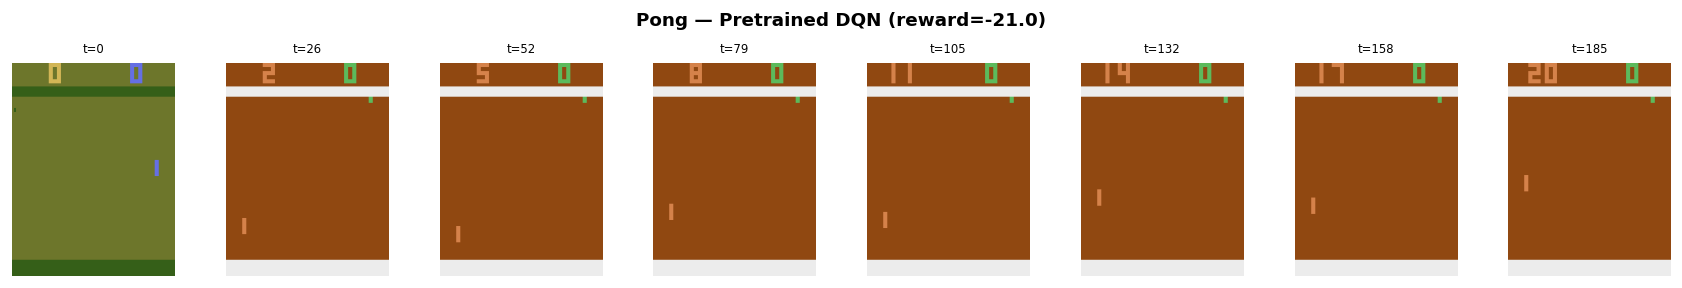

In [30]:
# ── 5.3  Pong — pretrained DQN ─────────────────────────────────────────────
#
# The pretrained model expects: grayscale 84x84, 4 frames stacked (shape: 4,84,84)
# We wrap the env with AtariPreprocessing + FrameStackObservation for inference,
# but capture raw RGB frames from the underlying env for visualisation.

from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation

def run_multiple_episodes(env_id, model=None, n_episodes=5, seed_start=0):
    """Run n episodes and return list of total rewards."""
    rewards = []
    for i in range(n_episodes):
        if model is None:
            env = gym.make(env_id, render_mode='rgb_array')
            _, total, _ = run_episode(env, model=None, seed=seed_start + i)
            env.close()
        else:
            _, total, _ = run_episode_pretrained(
                env_id, model, max_frames=2000, seed=seed_start + i)
        rewards.append(total)
        print(f'  Episode {i+1}/{n_episodes}: reward = {total:.1f}')
    return rewards


frames_pong_dqn, reward_pong_dqn, step_rew_pong_dqn = run_episode_pretrained(
    'ALE/Pong-v5', model_pong, max_frames=2000, seed=0)

print(f'Total reward (pretrained DQN): {reward_pong_dqn:.1f}')
print(f'Episode length: {len(step_rew_pong_dqn)} steps')
print(f'Improvement over random: {reward_pong_dqn - reward_pong_rand:+.1f} points')

show_episode_frames(frames_pong_dqn, f'Pong — Pretrained DQN (reward={reward_pong_dqn:.1f})')

In [32]:
# ── 5.4  Pong — multiple episodes for statistical comparison ──────────────

N_EPS = 5

print('Random agent:')
pong_rand_rewards = run_multiple_episodes('ALE/Pong-v5', model=None, n_episodes=N_EPS)

print('\nPretrained DQN:')
pong_dqn_rewards = run_multiple_episodes('ALE/Pong-v5', model=model_pong, n_episodes=N_EPS)

print(f'\nRandom  mean ± std: {np.mean(pong_rand_rewards):.1f} ± {np.std(pong_rand_rewards):.1f}')
print(f'DQN     mean ± std: {np.mean(pong_dqn_rewards):.1f} ± {np.std(pong_dqn_rewards):.1f}')

Random agent:
  Episode 1/5: reward = -19.0
  Episode 2/5: reward = -17.0
  Episode 3/5: reward = -20.0
  Episode 4/5: reward = -20.0
  Episode 5/5: reward = -18.0

Pretrained DQN:
  Episode 1/5: reward = -21.0
  Episode 2/5: reward = -21.0
  Episode 3/5: reward = -21.0
  Episode 4/5: reward = -21.0
  Episode 5/5: reward = -21.0

Random  mean ± std: -18.8 ± 1.2
DQN     mean ± std: -21.0 ± 0.0


# Part 6 — MsPacman: Random Agent vs Pretrained DQN

**MsPacman** is substantially harder than Pong. The game requires:
- Navigating a maze (spatial memory)
- Collecting pellets (dense sub-rewards)
- Avoiding 4 ghosts (multi-agent pursuit-evasion)
- Strategically eating power pellets to reverse the chase (mode switching)

**Reward structure:**  
- +10 per dot, +50 per power pellet, +200/400/800/1600 per ghost eaten (exponential bonus for chains)
- Dense — the agent receives rewards continuously as it navigates

**Physics framing:** MsPacman can be modelled as a **pursuit-evasion game on a graph** (the maze grid).  
Ghosts follow deterministic or stochastic policies; the agent's policy must form a Nash equilibrium  
in the resulting multi-player game — connecting directly to Week 7's multi-agent framework.

Running random agent on MsPacman...
Total reward (random): 80.0
Episode length: 385 steps


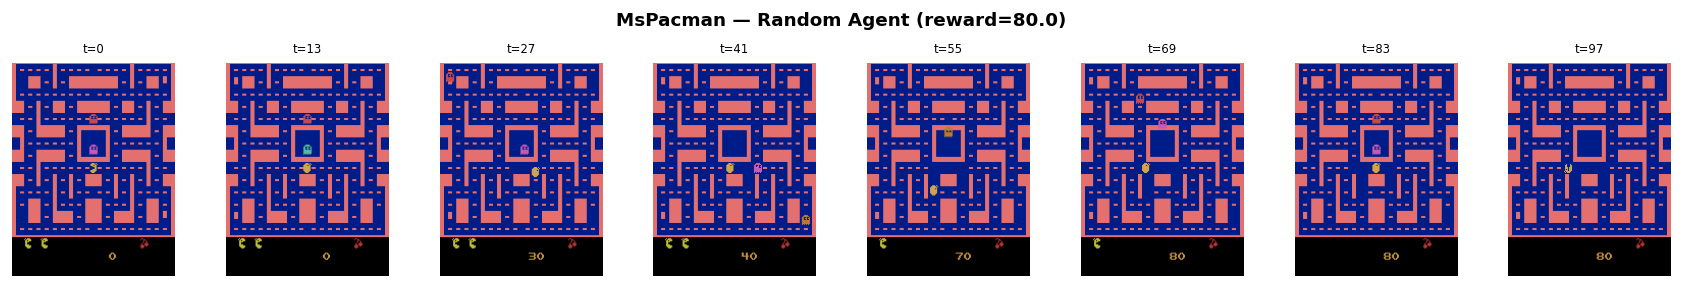

In [33]:
# ── 6.1  MsPacman — random agent ──────────────────────────────────────────

print('Running random agent on MsPacman...')
env_pac = gym.make('ALE/MsPacman-v5', render_mode='rgb_array')
frames_pac_rand, reward_pac_rand, step_rew_pac_rand = run_episode(
    env_pac, model=None, max_frames=2000, seed=0)
env_pac.close()

print(f'Total reward (random): {reward_pac_rand:.1f}')
print(f'Episode length: {len(step_rew_pac_rand)} steps')

show_episode_frames(frames_pac_rand, f'MsPacman — Random Agent (reward={reward_pac_rand:.1f})')

In [34]:
# ── 6.2  Load pretrained DQN for MsPacman ─────────────────────────────────
print('Downloading pretrained DQN for MsPacman...')

model_path_pac = hf_hub_download(
    repo_id='sb3/dqn-MsPacmanNoFrameskip-v4',
    filename='dqn-MsPacmanNoFrameskip-v4.zip'
)

model_pac = DQN.load(model_path_pac)
print(f'Model loaded. Policy: {type(model_pac.policy).__name__}')

dqn-MsPacmanNoFrameskip-v4.zip:   0%|          | 0.00/27.2M [00:00<?, ?B/s]

Model loaded. Policy: CnnPolicy


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:165: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  deserialized_object = cloudpickle.loads(base64_object)


Total reward (pretrained DQN): 210.0
Episode length: 353 steps
Improvement over random: +130.0 points


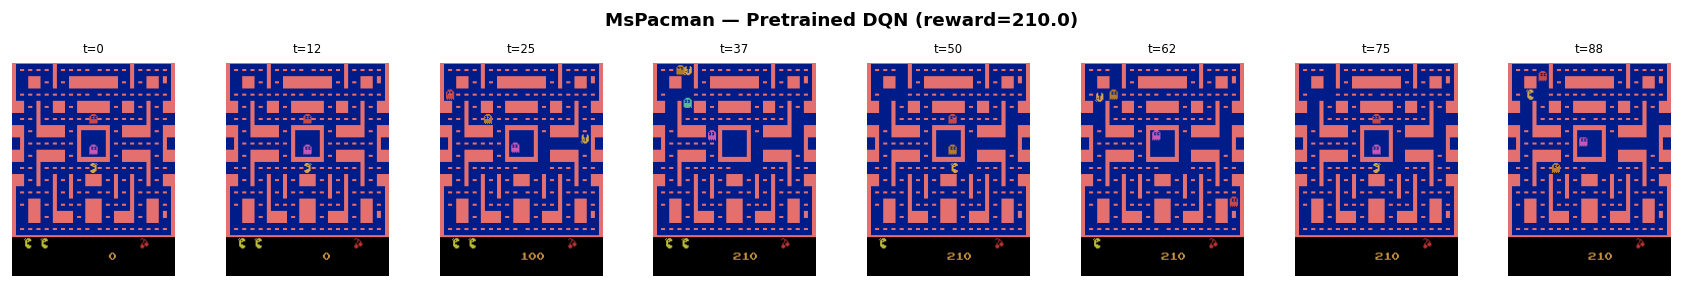

In [35]:
# ── 6.3  MsPacman — pretrained DQN ────────────────────────────────────────

frames_pac_dqn, reward_pac_dqn, step_rew_pac_dqn = run_episode_pretrained(
    'ALE/MsPacman-v5', model_pac, max_frames=2000, seed=0)

print(f'Total reward (pretrained DQN): {reward_pac_dqn:.1f}')
print(f'Episode length: {len(step_rew_pac_dqn)} steps')
print(f'Improvement over random: {reward_pac_dqn - reward_pac_rand:+.1f} points')

show_episode_frames(frames_pac_dqn, f'MsPacman — Pretrained DQN (reward={reward_pac_dqn:.1f})')

In [36]:
# ── 6.4  MsPacman — multiple episodes ─────────────────────────────────────

print('Random agent:')
pac_rand_rewards = run_multiple_episodes('ALE/MsPacman-v5', model=None, n_episodes=N_EPS)

print('\nPretrained DQN:')
pac_dqn_rewards = run_multiple_episodes('ALE/MsPacman-v5', model=model_pac, n_episodes=N_EPS)

print(f'\nRandom  mean ± std: {np.mean(pac_rand_rewards):.1f} ± {np.std(pac_rand_rewards):.1f}')
print(f'DQN     mean ± std: {np.mean(pac_dqn_rewards):.1f} ± {np.std(pac_dqn_rewards):.1f}')

Random agent:
  Episode 1/5: reward = 160.0
  Episode 2/5: reward = 170.0
  Episode 3/5: reward = 160.0
  Episode 4/5: reward = 210.0
  Episode 5/5: reward = 200.0

Pretrained DQN:
  Episode 1/5: reward = 210.0
  Episode 2/5: reward = 210.0
  Episode 3/5: reward = 210.0
  Episode 4/5: reward = 210.0
  Episode 5/5: reward = 210.0

Random  mean ± std: 180.0 ± 21.0
DQN     mean ± std: 210.0 ± 0.0


# Part 7 — Quantitative Comparison

We now compare the four (agent, game) combinations on three metrics:

| Metric | What it measures |
|--------|------------------|
| Mean episode reward | Overall performance |
| Reward distribution | Variance and stability |
| Cumulative reward curve | Strategy within an episode |

The cumulative reward curve is particularly informative: a random agent accumulates reward diffusively (random walk), while a trained agent shows deterministic plateaus and sharp transitions.

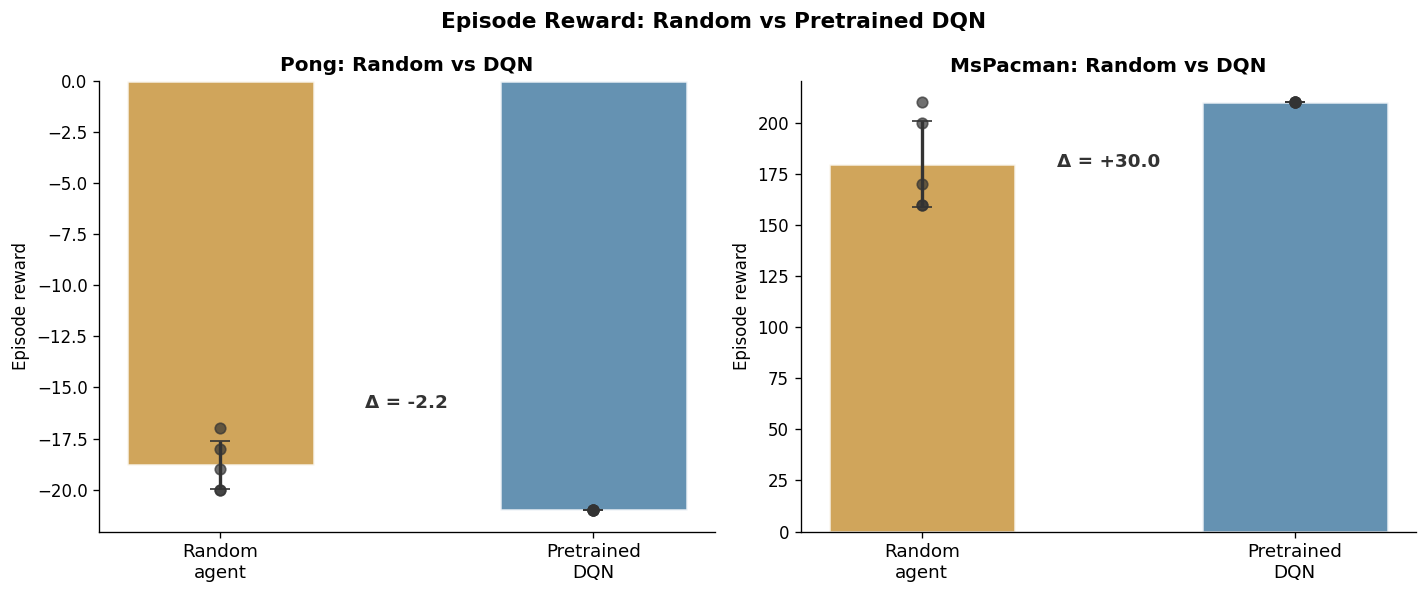

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [37]:
# ── 7.1  Bar comparison: mean rewards ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, game, rand_r, dqn_r, rand_m, dqn_m in [
    (axes[0], 'Pong',     pong_rand_rewards, pong_dqn_rewards,
                          np.mean(pong_rand_rewards), np.mean(pong_dqn_rewards)),
    (axes[1], 'MsPacman', pac_rand_rewards,  pac_dqn_rewards,
                          np.mean(pac_rand_rewards),  np.mean(pac_dqn_rewards)),
]:
    x = [0, 1]
    means = [rand_m, dqn_m]
    colors_bar = ['#C8963E', '#4A7FA5']
    bars = ax.bar(x, means, color=colors_bar, width=0.5, alpha=0.85,
                  edgecolor='white', linewidth=1.5)

    # Individual episode dots
    for xi, rewards in zip(x, [rand_r, dqn_r]):
        ax.scatter([xi] * len(rewards), rewards, color='#333333',
                   zorder=5, s=40, alpha=0.7)

    # Error bars
    ax.errorbar(x, means,
                yerr=[np.std(rand_r), np.std(dqn_r)],
                fmt='none', color='#333333', capsize=6, linewidth=2)

    ax.set_xticks(x)
    ax.set_xticklabels(['Random\nagent', 'Pretrained\nDQN'], fontsize=11)
    ax.set_ylabel('Episode reward', fontsize=10)
    ax.set_title(f'{game}: Random vs DQN', fontsize=12, weight='bold')

    # Improvement annotation
    improvement = dqn_m - rand_m
    ax.annotate(f'Δ = {improvement:+.1f}',
                xy=(0.5, max(means) * 0.85),
                ha='center', fontsize=11, color='#333333',
                weight='bold')

plt.suptitle('Episode Reward: Random vs Pretrained DQN', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

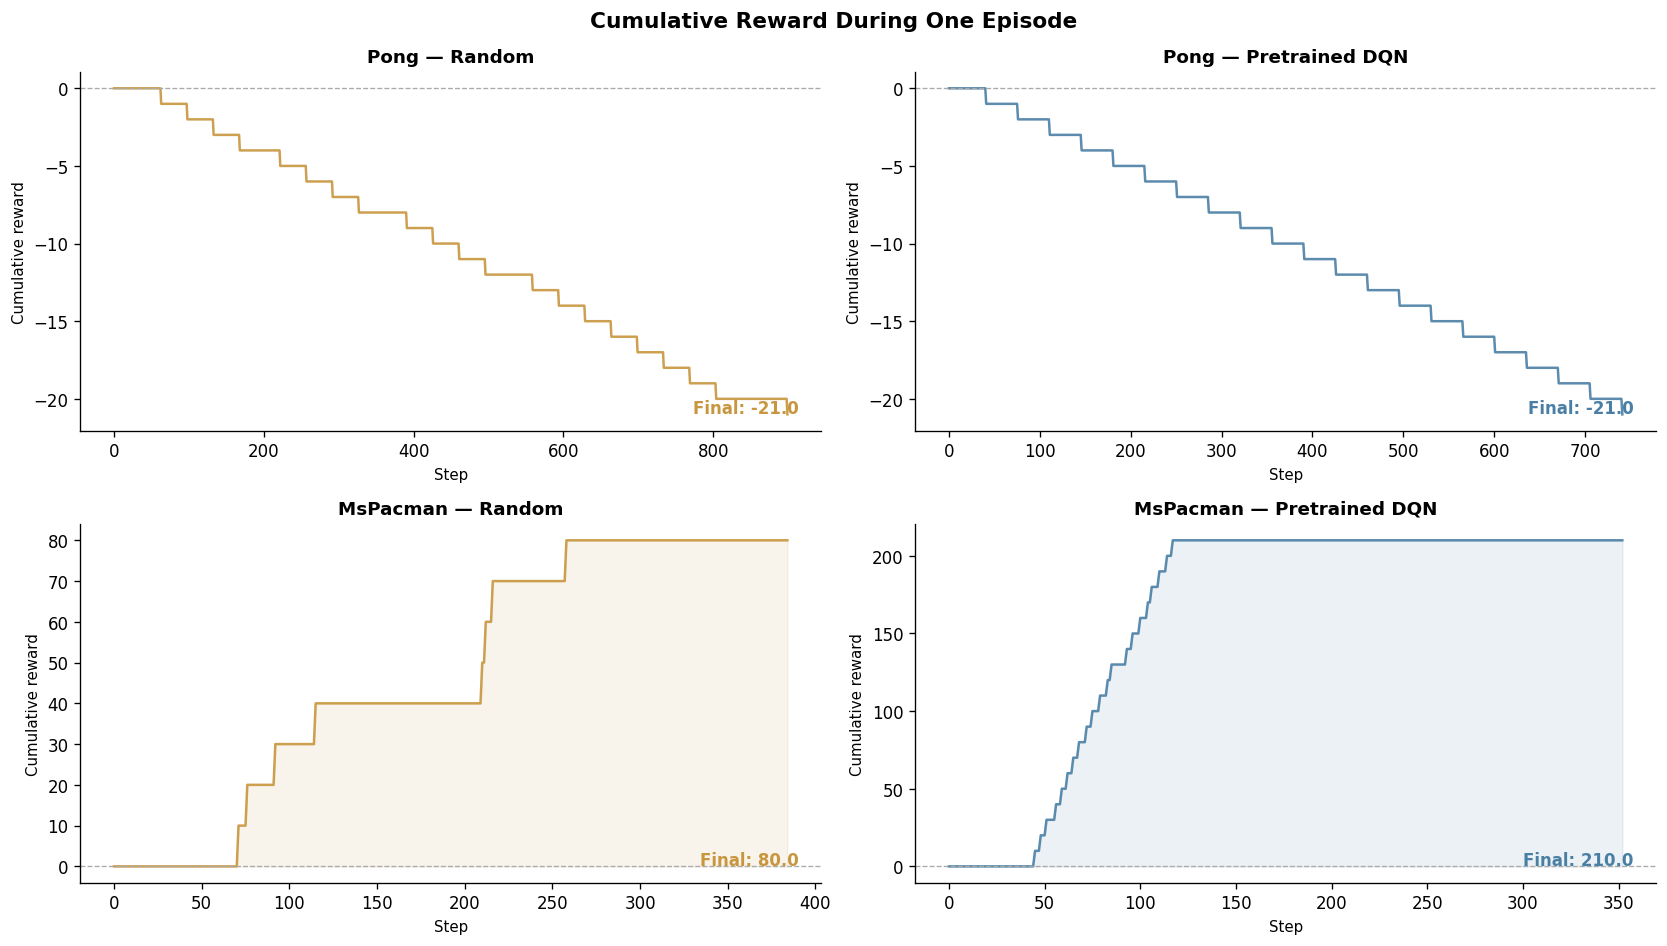


Physics interpretation:
  Random agent:  cumulative reward ~ random walk (diffusive, σ ~ √t)
  Trained DQN:   cumulative reward ~ ballistic motion (deterministic drift)
  The crossover step is where the agent starts exploiting its learned policy.


In [38]:
# ── 7.2  Cumulative reward curves within one episode ──────────────────────
#
# This shows HOW reward accumulates over time.
# Random agent: jagged random walk
# Trained DQN:  sustained positive increments with structure

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

datasets = [
    (axes[0, 0], 'Pong — Random',        step_rew_pong_rand,  '#C8963E'),
    (axes[0, 1], 'Pong — Pretrained DQN', step_rew_pong_dqn,  '#4A7FA5'),
    (axes[1, 0], 'MsPacman — Random',     step_rew_pac_rand,   '#C8963E'),
    (axes[1, 1], 'MsPacman — Pretrained DQN', step_rew_pac_dqn, '#4A7FA5'),
]

for ax, title, step_rewards, color in datasets:
    cumulative = np.cumsum(step_rewards)
    steps = np.arange(len(cumulative))

    ax.plot(steps, cumulative, color=color, lw=1.5, alpha=0.9)
    ax.fill_between(steps, 0, cumulative,
                    where=(np.array(cumulative) >= 0),
                    color=color, alpha=0.1)
    ax.axhline(0, color='#AAAAAA', lw=0.8, ls='--')

    final = cumulative[-1]
    ax.text(0.97, 0.05, f'Final: {final:.1f}',
            transform=ax.transAxes, ha='right', fontsize=10,
            color=color, weight='bold')

    ax.set_title(title, fontsize=11, weight='bold')
    ax.set_xlabel('Step', fontsize=9)
    ax.set_ylabel('Cumulative reward', fontsize=9)

plt.suptitle('Cumulative Reward During One Episode', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

print()
print('Physics interpretation:')
print('  Random agent:  cumulative reward ~ random walk (diffusive, σ ~ √t)')
print('  Trained DQN:   cumulative reward ~ ballistic motion (deterministic drift)')
print('  The crossover step is where the agent starts exploiting its learned policy.')

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

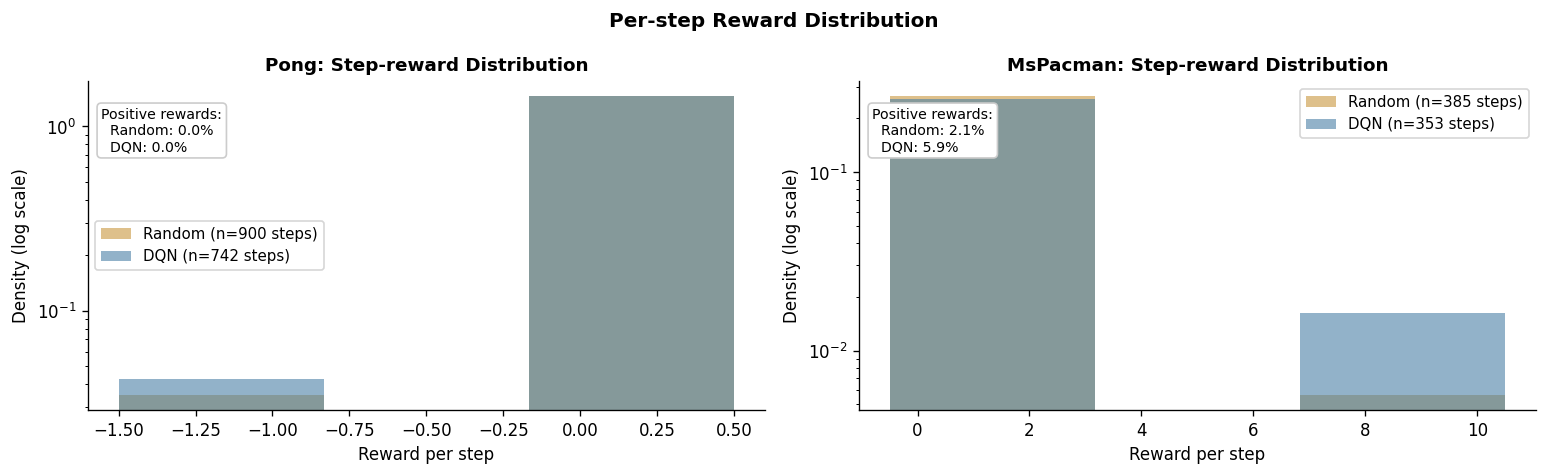

In [39]:
# ── 7.3  Reward-per-step distribution ─────────────────────────────────────
#
# Random agent: concentrated near 0 (sparse in both games)
# Trained DQN:  shifted toward positive values, heavy tail

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, title, rand_r, dqn_r in [
    (axes[0], 'Pong', step_rew_pong_rand, step_rew_pong_dqn),
    (axes[1], 'MsPacman', step_rew_pac_rand, step_rew_pac_dqn),
]:
    all_values = sorted(set(rand_r + dqn_r))

    # Count non-zero rewards
    rand_nonzero = [r for r in rand_r if r != 0]
    dqn_nonzero  = [r for r in dqn_r  if r != 0]

    bins = np.linspace(min(all_values) - 0.5, max(all_values) + 0.5,
                       len(all_values) + 2)

    ax.hist(rand_r, bins=bins, alpha=0.6, color='#C8963E',
            label=f'Random (n={len(rand_r)} steps)', density=True)
    ax.hist(dqn_r,  bins=bins, alpha=0.6, color='#4A7FA5',
            label=f'DQN (n={len(dqn_r)} steps)', density=True)

    ax.set_yscale('log')
    ax.set_xlabel('Reward per step', fontsize=10)
    ax.set_ylabel('Density (log scale)', fontsize=10)
    ax.set_title(f'{title}: Step-reward Distribution', fontsize=11, weight='bold')
    ax.legend(fontsize=9)

    rand_pos_frac = sum(r > 0 for r in rand_r) / len(rand_r)
    dqn_pos_frac  = sum(r > 0 for r in dqn_r)  / len(dqn_r)
    ax.text(0.02, 0.92, f'Positive rewards:\n  Random: {rand_pos_frac:.1%}\n  DQN: {dqn_pos_frac:.1%}',
            transform=ax.transAxes, fontsize=8.5, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#CCCCCC'))

plt.suptitle('Per-step Reward Distribution', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

In [40]:
# ── 7.4  Summary table ─────────────────────────────────────────────────────

print(f'{"":30}  {"Random mean":>12}  {"DQN mean":>12}  {"Δ":>10}  {"Ratio DQN/Random":>17}')
print('-' * 85)

for game, rand_r, dqn_r in [
    ('Pong',     pong_rand_rewards, pong_dqn_rewards),
    ('MsPacman', pac_rand_rewards,  pac_dqn_rewards),
]:
    rm = np.mean(rand_r)
    dm = np.mean(dqn_r)
    delta = dm - rm
    ratio = dm / rm if rm != 0 else float('inf')
    print(f'{game:<30}  {rm:>12.1f}  {dm:>12.1f}  {delta:>+10.1f}  {ratio:>17.2f}x')

print()
print('Note: ratio DQN/random > 1 confirms the pretrained policy substantially')
print('outperforms random exploration in both environments.')

                                 Random mean      DQN mean           Δ   Ratio DQN/Random
-------------------------------------------------------------------------------------
Pong                                   -18.8         -21.0        -2.2               1.12x
MsPacman                               180.0         210.0       +30.0               1.17x

Note: ratio DQN/random > 1 confirms the pretrained policy substantially
outperforms random exploration in both environments.


# Part 8 — Exercises

---

### Exercise 1 — Registry exploration

Using `gymnasium.envs.registry`, write a function that:
1. Lists all environments with `max_episode_steps > 1000`
2. Computes the histogram of `max_episode_steps` values across all environments
3. Identifies which environment has the highest `max_episode_steps`

What does the distribution of `max_episode_steps` tell you about the typical difficulty horizon in RL benchmarks?

---

### Exercise 2 — Phase diagram classification

Pick any 5 environments from the registry that were **not** discussed in this notebook.  
For each one:
1. Instantiate the environment and inspect its `observation_space` and `action_space`
2. Classify it in the 2×2 phase diagram (discrete/continuous × sparse/dense)
3. State which algorithm family (tabular / DQN / PPO / SAC) you would use and why

*Hint: reward density is not always obvious from the spec — read the documentation or step through a few random actions and examine the reward values.*

---

### Exercise 3 — Diffusive vs ballistic reward accumulation

In section 7.2 we claimed:
- Random agent: cumulative reward ~ random walk, $\sigma_{\text{cumulative}} \sim \sqrt{t}$
- Trained DQN: cumulative reward ~ ballistic, $\sigma_{\text{cumulative}} \sim t$

Test this claim quantitatively:
1. Run 20 episodes each for the random agent on Pong
2. At each step $t$, compute the **standard deviation across episodes** of the cumulative reward $G_t$
3. Plot $\sigma(G_t)$ vs $t$ on a log-log scale
4. Fit a power law $\sigma \sim t^{\alpha}$ and report $\alpha$

Is $\alpha \approx 0.5$ (diffusive) or $\alpha \approx 1$ (ballistic)?

---

### Exercise 4 (advanced) — MsPacman as a pursuit-evasion game

MsPacman involves 4 ghosts, each with a known deterministic policy (Blinky, Pinky, Inky, Clyde).  
Model the game as a **two-player zero-sum game** where:
- Player 1 (MsPacman) maximises score
- Player 2 (ghosts) minimises MsPacman's survival time

1. What is the state space of this game? (estimate the number of states)
2. Why is the Nash equilibrium of this game not achievable by a tabular method?
3. How does the power-pellet mechanic change the game structure?
   *(Hint: it is a mode switch that inverts the payoff matrix for ~10 seconds)*

Connect your analysis to the Prisoner's Dilemma framing from Week 7:
what is the analogue of cooperation/defection in the ghost-pacman game?

---

### Exercise 5 (project) — Train DQN from scratch on Pong

```python
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack

vec_env = make_atari_env('ALE/Pong-v5', n_envs=4, seed=0)
vec_env = VecFrameStack(vec_env, n_stack=4)

model = DQN('CnnPolicy', vec_env,
            buffer_size=100_000,
            learning_starts=10_000,
            batch_size=32,
            verbose=1)

model.learn(total_timesteps=1_000_000)
```

Train for 1M steps (≈ 20 min on GPU Colab).  
Plot the learning curve and compare your trained model to the pretrained one from Part 5.  
How many steps does it take to first beat the random agent baseline?  
At what step does the mean episode reward cross 0? Cross +10?

This is the canonical experiment from Mnih et al. (2015) at 1/10 the original scale.

---

## Connection to Week 7 — Multi-Agent RL

The Gymnasium ecosystem we have mapped this week uses a **single-agent interface**:  
one agent, one environment, one reward signal.

In Week 7 we move to **multi-agent systems** where:
- Multiple agents act simultaneously in a shared environment
- Each agent has its own observation, action, and reward
- The state transitions depend on the **joint action** of all agents

The multi-agent analogue of Gymnasium is **PettingZoo** (Farama Foundation, same team).  
It uses a compatible API — the `env.step(action)` loop extends naturally to `env.step(actions_dict)`.

MsPacman already hints at this: the 4 ghosts are agents with their own policies.  
In Week 7 we will formalise this as a **game** and introduce Nash equilibrium as the  
multi-agent analogue of the Bellman-optimal policy.

| This week (Gymnasium) | Next week (PettingZoo) |
|----------------------|------------------------|
| Single agent | Multiple agents |
| `env.step(action)` | `env.step(action)` per agent |
| Bellman optimality | Nash equilibrium |
| V*(s) — optimal value | V*(s) — Nash value function |
| ε-greedy exploration | Joint exploration (correlated) |
| Reward: maximise return | Reward: maximise *given opponents' policies* |

---
*From Conway to LangGraph · Week 6 · Università di Bologna, Dipartimento di Fisica*